In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

✅ Libraries imported!


In [2]:
feature_df = pd.read_parquet('../data/processed/features_for_ml.parquet')

print(f"✅ Feature data loaded!")
print(f"Shape: {feature_df.shape}")
print(f"Columns: {feature_df.columns.tolist()}")
feature_df.head()

✅ Feature data loaded!
Shape: (143846, 20)
Columns: ['date', 'hour', 'PULocationID', 'demand', 'avg_distance', 'avg_fare', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'is_morning_rush', 'is_evening_rush', 'is_night', 'is_business_hours', 'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h', 'demand_rolling_mean_3h', 'demand_rolling_max_6h', 'demand_rolling_std_6h']


,date,hour,PULocationID,demand,avg_distance,avg_fare,day_of_week,day_of_month,month,is_weekend,is_morning_rush,is_evening_rush,is_night,is_business_hours,demand_lag_1h,demand_lag_24h,demand_lag_168h,demand_rolling_mean_3h,demand_rolling_max_6h,demand_rolling_std_6h
0,2025-10-31,19,3,1,7.700,39.50,4,31,10,0,0,1,0,0,1.0,1.0,3.0,1.0,2.0,0.408248
1,2025-11-01,16,3,1,10.500,40.50,5,1,11,1,0,0,0,1,1.0,1.0,1.0,1.0,1.0,0.000000
2,2025-11-02,9,3,1,1.800,18.50,6,2,11,1,1,0,0,1,1.0,1.0,1.0,1.0,1.0,0.000000
3,2025-11-03,0,3,1,18.200,55.50,0,3,11,0,0,0,1,0,1.0,1.0,1.0,1.0,1.0,0.000000
4,2025-11-03,6,3,4,13.725,44.25,0,3,11,0,0,0,0,0,1.0,1.0,1.0,1.0,1.0,0.000000


In [3]:
split_idx = int(len(feature_df) * 0.8)

train_df = feature_df.iloc[:split_idx]
test_df = feature_df.iloc[split_idx:]

print("="*60)
print("TRAIN/TEST SPLIT")
print("="*60)
print(f"Training period: {train_df['date'].min()} to {train_df['date'].max()}")
print(f"Test period:     {test_df['date'].min()} to {test_df['date'].max()}")
print(f"\nTraining samples: {len(train_df):,}")
print(f"Test samples:     {len(test_df):,}")
print("="*60)

TRAIN/TEST SPLIT
Training period: 2025-10-07 00:00:00 to 2025-11-30 00:00:00
Test period:     2025-10-07 00:00:00 to 2025-11-30 00:00:00

Training samples: 115,076
Test samples:     28,770


In [4]:
feature_cols = [
    'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend',
    'is_morning_rush', 'is_evening_rush', 'is_night', 'is_business_hours',
    'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h',
    'demand_rolling_mean_3h', 'demand_rolling_max_6h', 'demand_rolling_std_6h',
    'avg_distance', 'avg_fare'
]

# Prepare X (features) and y (target)
X_train = train_df[feature_cols]
y_train = train_df['demand']

X_test = test_df[feature_cols]
y_test = test_df['demand']

print("✅ Features and target prepared!")
print(f"\nFeatures being used ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

✅ Features and target prepared!

Features being used (17):
  1. hour
  2. day_of_week
  3. day_of_month
  4. month
  5. is_weekend
  6. is_morning_rush
  7. is_evening_rush
  8. is_night
  9. is_business_hours
  10. demand_lag_1h
  11. demand_lag_24h
  12. demand_lag_168h
  13. demand_rolling_mean_3h
  14. demand_rolling_max_6h
  15. demand_rolling_std_6h
  16. avg_distance
  17. avg_fare


In [5]:
print("\n" + "="*60)
print("TRAINING XGBOOST MODEL")
print("="*60)

# Define model parameters
model = xgb.XGBRegressor(
    objective='reg:squarederror',  # Regression task
    max_depth=6,                    # Tree depth (controls complexity)
    learning_rate=0.1,              # Step size shrinkage
    n_estimators=200,               # Number of trees
    subsample=0.8,                  # Row sampling ratio
    colsample_bytree=0.8,           # Column sampling ratio
    random_state=42,                # Reproducibility
    n_jobs=-1,                      # Use all CPU cores
    verbosity=1                     # Show progress
)

# Train the model with evaluation
print("\n🚀 Training started...\n")

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_metric='rmse',
    verbose=25  # Print progress every 25 trees
)

print("\n✅ Training complete!")


TRAINING XGBOOST MODEL

🚀 Training started...

[0]	validation_0-rmse:60.29408	validation_1-rmse:89.43967
[25]	validation_0-rmse:14.54952	validation_1-rmse:23.56725
[50]	validation_0-rmse:12.57764	validation_1-rmse:21.72613
[75]	validation_0-rmse:11.81135	validation_1-rmse:21.19773
[100]	validation_0-rmse:11.22523	validation_1-rmse:21.02218
[125]	validation_0-rmse:10.77766	validation_1-rmse:20.89618
[150]	validation_0-rmse:10.38267	validation_1-rmse:20.75900
[175]	validation_0-rmse:10.06349	validation_1-rmse:20.69560
[199]	validation_0-rmse:9.77911	validation_1-rmse:20.64610

✅ Training complete!


In [6]:
print("\nMaking predictions...")

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("✅ Predictions complete!")


Making predictions...
✅ Predictions complete!


In [7]:
def evaluate_model(y_true, y_pred, dataset_name):
    """Calculate and display metrics"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # MAPE (Mean Absolute Percentage Error)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{dataset_name} Metrics:")
    print(f"  RMSE: {rmse:.2f} trips")
    print(f"  MAE:  {mae:.2f} trips")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape}

print("="*60)
print("MODEL PERFORMANCE")
print("="*60)

train_metrics = evaluate_model(y_train, y_train_pred, "TRAINING SET")
test_metrics = evaluate_model(y_test, y_test_pred, "TEST SET")

print("\n" + "="*60)

# Check for overfitting
if train_metrics['r2'] - test_metrics['r2'] > 0.1:
    print("⚠️  Warning: Model might be overfitting (train R² much higher than test R²)")
else:
    print("✅ Model generalization looks good!")

MODEL PERFORMANCE

TRAINING SET Metrics:
  RMSE: 9.78 trips
  MAE:  4.77 trips
  R²:   0.9783
  MAPE: 51.81%

TEST SET Metrics:
  RMSE: 20.65 trips
  MAE:  10.18 trips
  R²:   0.9514
  MAPE: 43.83%

✅ Model generalization looks good!


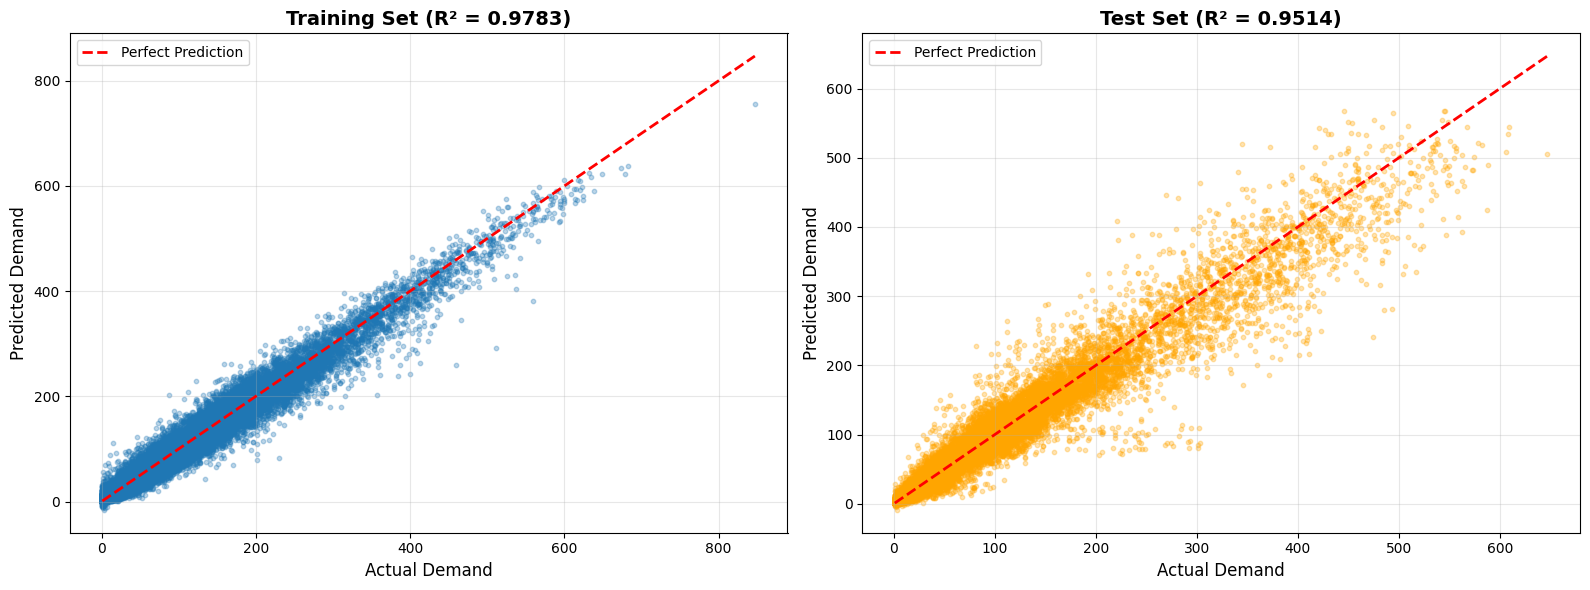

✅ Visualization saved to: outputs/figures/predictions_vs_actual.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training set
axes[0].scatter(y_train, y_train_pred, alpha=0.3, s=10)
axes[0].plot([y_train.min(), y_train.max()], 
             [y_train.min(), y_train.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Demand', fontsize=12)
axes[0].set_ylabel('Predicted Demand', fontsize=12)
axes[0].set_title(f'Training Set (R² = {train_metrics["r2"]:.4f})', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test set
axes[1].scatter(y_test, y_test_pred, alpha=0.3, s=10, color='orange')
axes[1].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Demand', fontsize=12)
axes[1].set_ylabel('Predicted Demand', fontsize=12)
axes[1].set_title(f'Test Set (R² = {test_metrics["r2"]:.4f})', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/predictions_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualization saved to: outputs/figures/predictions_vs_actual.png")

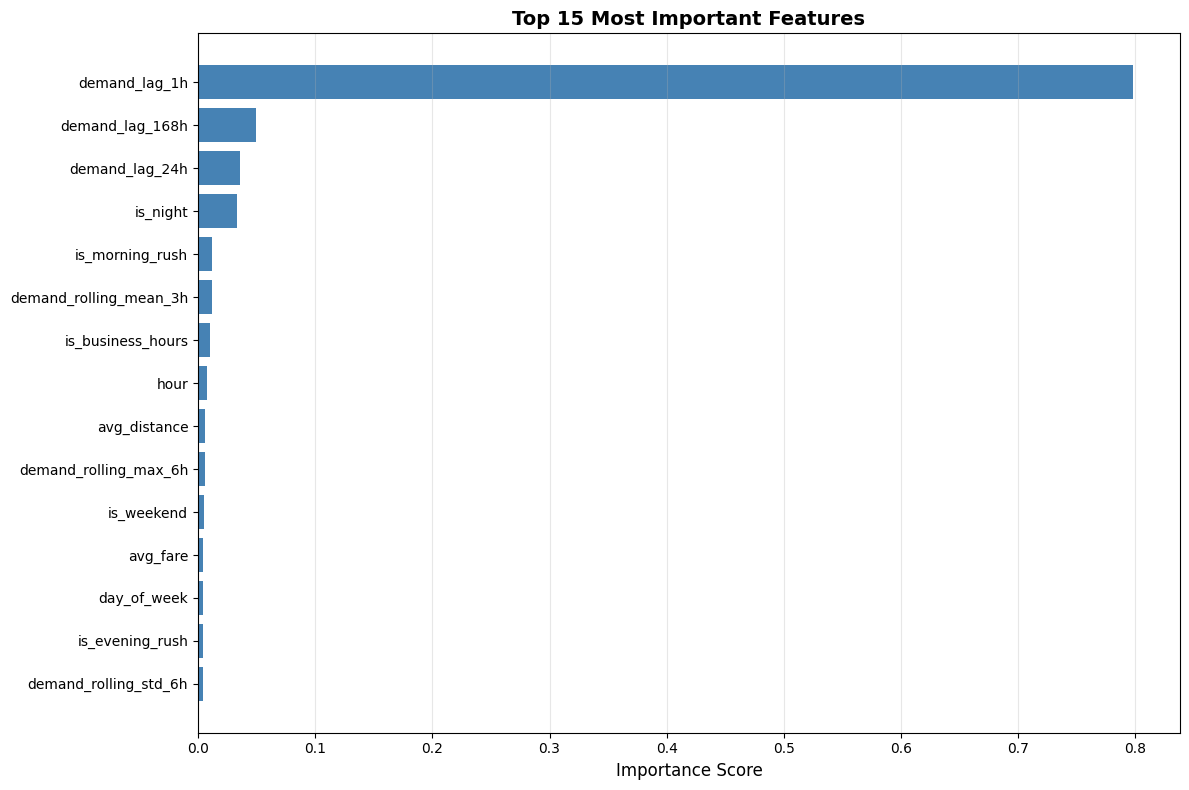


TOP 10 MOST IMPORTANT FEATURES:
  demand_lag_1h                  0.7982
  demand_lag_168h                0.0493
  demand_lag_24h                 0.0356
  is_night                       0.0335
  is_morning_rush                0.0120
  demand_rolling_mean_3h         0.0119
  is_business_hours              0.0106
  hour                           0.0079
  avg_distance                   0.0060
  demand_rolling_max_6h          0.0060


In [9]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(12, 8))
top_features = importance_df.head(15)
plt.barh(range(len(top_features)), top_features['importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 15 Most Important Features', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("TOP 10 MOST IMPORTANT FEATURES:")
print("="*60)
for idx, row in importance_df.head(10).iterrows():
    print(f"  {row['feature']:30s} {row['importance']:.4f}")

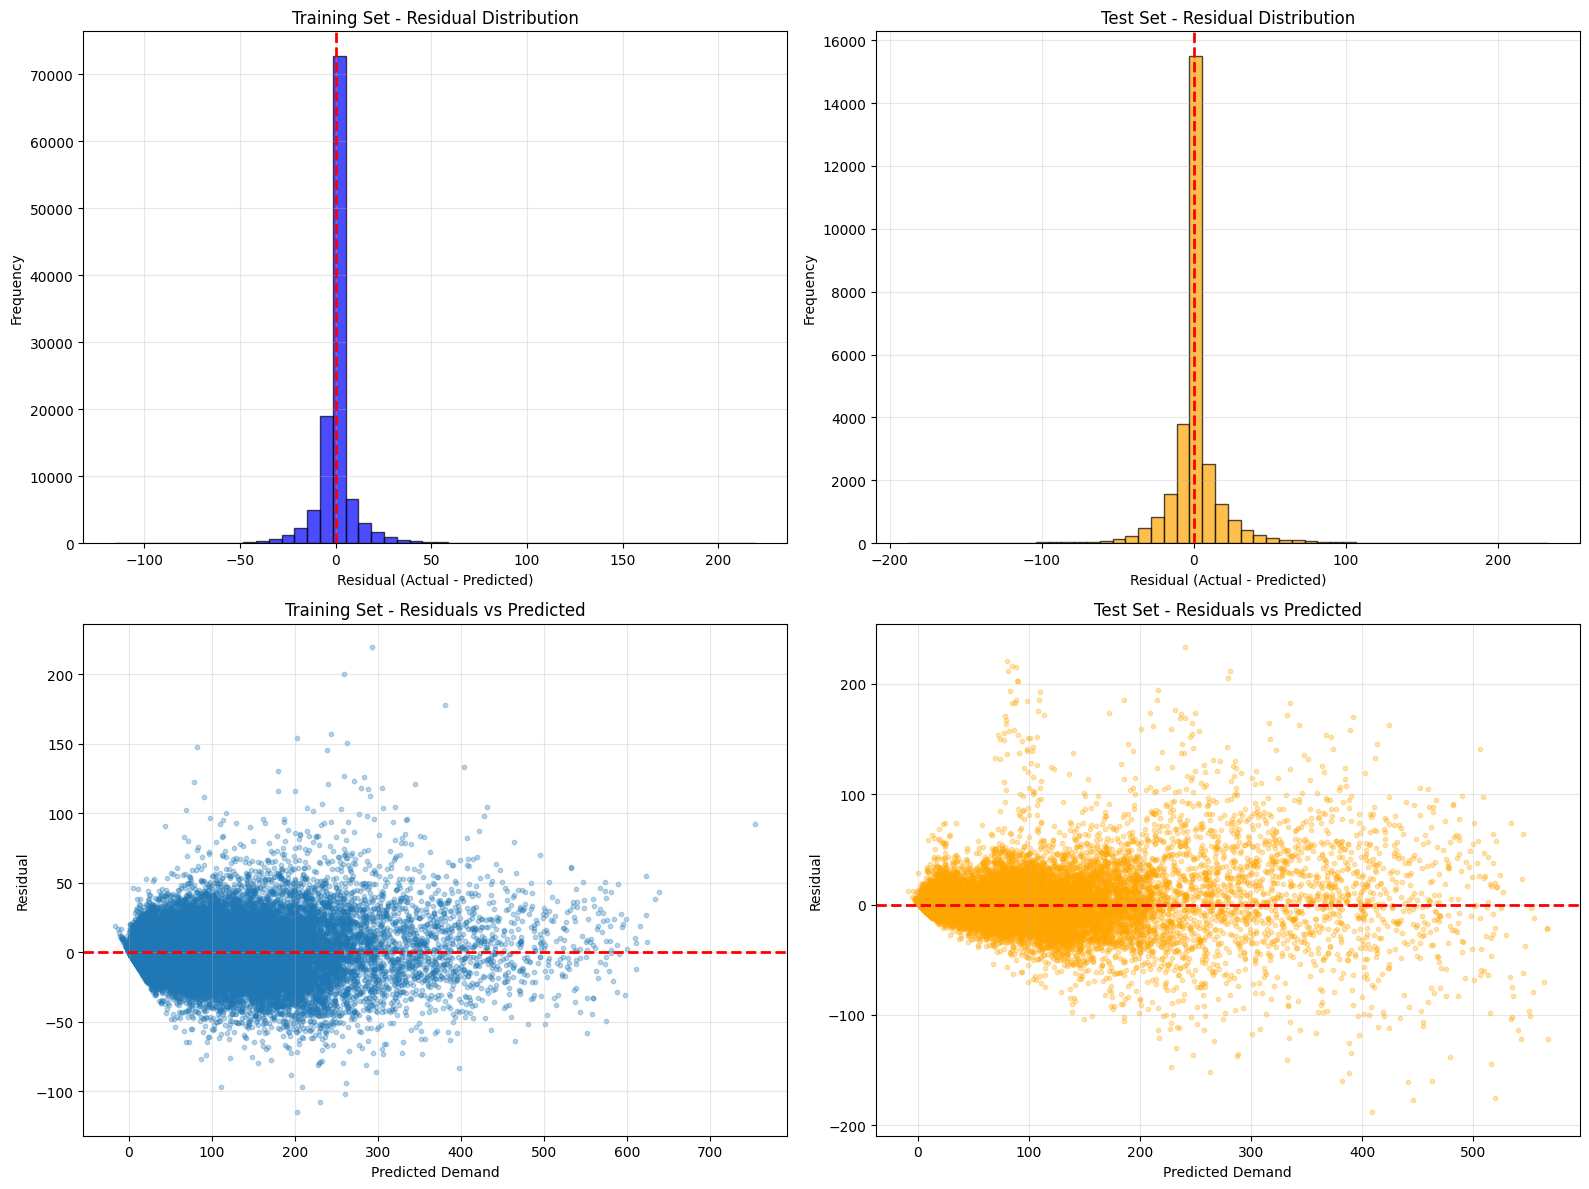

In [10]:
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Training residuals histogram
axes[0, 0].hist(train_residuals, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Residual (Actual - Predicted)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Training Set - Residual Distribution')
axes[0, 0].grid(True, alpha=0.3)

# Test residuals histogram
axes[0, 1].hist(test_residuals, bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Residual (Actual - Predicted)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Test Set - Residual Distribution')
axes[0, 1].grid(True, alpha=0.3)

# Training residuals vs predicted
axes[1, 0].scatter(y_train_pred, train_residuals, alpha=0.3, s=10)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Demand')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title('Training Set - Residuals vs Predicted')
axes[1, 0].grid(True, alpha=0.3)

# Test residuals vs predicted
axes[1, 1].scatter(y_test_pred, test_residuals, alpha=0.3, s=10, color='orange')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Predicted Demand')
axes[1, 1].set_ylabel('Residual')
axes[1, 1].set_title('Test Set - Residuals vs Predicted')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/residual_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
sample_zones = [237, 236, 161, 162, 132]  # Times Sq, Upper East, Midtown, JFK, etc.

print("\n" + "="*60)
print("SAMPLE PREDICTIONS FOR POPULAR ZONES")
print("="*60)

for zone in sample_zones:
    zone_test = test_df[test_df['PULocationID'] == zone].head(5)
    if len(zone_test) > 0:
        zone_pred = model.predict(zone_test[feature_cols])
        print(f"\nZone {zone}:")
        for idx, (actual, pred) in enumerate(zip(zone_test['demand'].values, zone_pred)):
            error = abs(actual - pred)
            print(f"  Sample {idx+1}: Actual={actual:.0f}, Predicted={pred:.1f}, Error={error:.1f}")


SAMPLE PREDICTIONS FOR POPULAR ZONES

Zone 237:
  Sample 1: Actual=18, Predicted=23.1, Error=5.1
  Sample 2: Actual=3, Predicted=9.6, Error=6.6
  Sample 3: Actual=2, Predicted=4.4, Error=2.4
  Sample 4: Actual=5, Predicted=2.5, Error=2.5
  Sample 5: Actual=8, Predicted=7.1, Error=0.9

Zone 236:
  Sample 1: Actual=1, Predicted=3.3, Error=2.3
  Sample 2: Actual=3, Predicted=3.7, Error=0.7
  Sample 3: Actual=12, Predicted=7.3, Error=4.7
  Sample 4: Actual=73, Predicted=34.6, Error=38.4
  Sample 5: Actual=245, Predicted=120.1, Error=124.9


In [12]:
import os
os.makedirs('../models', exist_ok=True)

# Save as JSON (XGBoost format)
model.save_model('../models/xgboost_demand_model.json')

# Also save with pickle for easier loading later
with open('../models/xgboost_demand_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save feature names
with open('../models/feature_names.txt', 'w') as f:
    f.write('\n'.join(feature_cols))

# Save model metadata
metadata = {
    'model_type': 'XGBoost Regressor',
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'train_samples': len(X_train),
    'test_samples': len(X_test),
    'features': feature_cols,
    'train_rmse': train_metrics['rmse'],
    'test_rmse': test_metrics['rmse'],
    'train_r2': train_metrics['r2'],
    'test_r2': test_metrics['r2'],
    'parameters': model.get_params()
}

import json
with open('../models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4, default=str)

print("\n" + "="*60)
print("MODEL SAVED!")
print("="*60)
print("✅ Model saved to: models/xgboost_demand_model.json")
print("✅ Model saved to: models/xgboost_demand_model.pkl")
print("✅ Feature names saved to: models/feature_names.txt")
print("✅ Metadata saved to: models/model_metadata.json")
print("\n🎉 MODEL TRAINING COMPLETE! 🎉")


MODEL SAVED!
✅ Model saved to: models/xgboost_demand_model.json
✅ Model saved to: models/xgboost_demand_model.pkl
✅ Feature names saved to: models/feature_names.txt
✅ Metadata saved to: models/model_metadata.json

🎉 MODEL TRAINING COMPLETE! 🎉


In [13]:
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"Model Type: XGBoost Regressor")
print(f"Number of Features: {len(feature_cols)}")
print(f"Training Samples: {len(X_train):,}")
print(f"Test Samples: {len(X_test):,}")
print(f"\nPerformance on Test Set:")
print(f"  - RMSE: {test_metrics['rmse']:.2f} trips")
print(f"  - MAE:  {test_metrics['mae']:.2f} trips")
print(f"  - R²:   {test_metrics['r2']:.4f}")
print(f"  - MAPE: {test_metrics['mape']:.2f}%")
print(f"\nTop 3 Most Important Features:")
for idx, row in importance_df.head(3).iterrows():
    print(f"  {idx+1}. {row['feature']} ({row['importance']:.4f})")
print("="*60)
print("\n✅ Your model is ready for deployment!")
print("📊 Check the outputs/figures/ folder for visualizations")


FINAL SUMMARY
Model Type: XGBoost Regressor
Number of Features: 17
Training Samples: 115,076
Test Samples: 28,770

Performance on Test Set:
  - RMSE: 20.65 trips
  - MAE:  10.18 trips
  - R²:   0.9514
  - MAPE: 43.83%

Top 3 Most Important Features:
  10. demand_lag_1h (0.7982)
  12. demand_lag_168h (0.0493)
  11. demand_lag_24h (0.0356)

✅ Your model is ready for deployment!
📊 Check the outputs/figures/ folder for visualizations
